In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("../outputs/Charts").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/processed/final_womens_development_index.csv")

df.head()

,Country Name,Country Code,adolescent_fertility,gdp_per_capita,female_labor_force_participation,female_life_expectancy,maternal_mortality,women_in_parliament,female_secondary_enrollment,female_tertiary_enrollment,...,female_life_expectancy_norm,women_in_parliament_norm,female_unemployment_norm,maternal_mortality_norm,adolescent_fertility_norm,education_index,economic_participation_index,health_index,political_representation_index,womens_development_index
0,Finland,FIN,3.095,52834.291675,57.489,84.3,8.0,46.000000,151.367447,123.140877,...,0.886347,0.751020,0.844056,0.992944,0.982809,0.853936,0.759592,0.954033,0.751020,0.829645
1,Iceland,ISL,3.369,82138.789297,70.368,84.3,3.0,47.619048,106.320831,104.202988,...,0.886347,0.777454,0.927243,0.997984,0.981018,0.647533,0.883623,0.955116,0.777454,0.815931
2,Sweden,SWE,1.792,54950.283473,61.685,85.0,4.0,46.418338,143.316437,104.125679,...,0.907338,0.757850,0.807540,0.996976,0.991326,0.770771,0.768192,0.965213,0.757850,0.815507
3,Norway,NOR,1.405,87497.217965,62.371,84.6,1.0,46.153846,116.642189,114.607201,...,0.895343,0.753532,0.918422,1.000000,0.993856,0.712781,0.828024,0.963066,0.753532,0.814351
4,Australia,AUS,6.715,65058.377315,62.576,85.1,2.0,38.410596,131.097336,125.171501,...,0.910337,0.627112,0.915456,0.998992,0.959146,0.792299,0.827854,0.956158,0.627112,0.800856


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
cluster_features = [
    "education_index",
    "economic_participation_index",
    "health_index",
    "political_representation_index"
]

X = df[cluster_features].copy()

X.head()

,education_index,economic_participation_index,health_index,political_representation_index
0,0.853936,0.759592,0.954033,0.751020
1,0.647533,0.883623,0.955116,0.777454
2,0.770771,0.768192,0.965213,0.757850
3,0.712781,0.828024,0.963066,0.753532
4,0.792299,0.827854,0.956158,0.627112


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


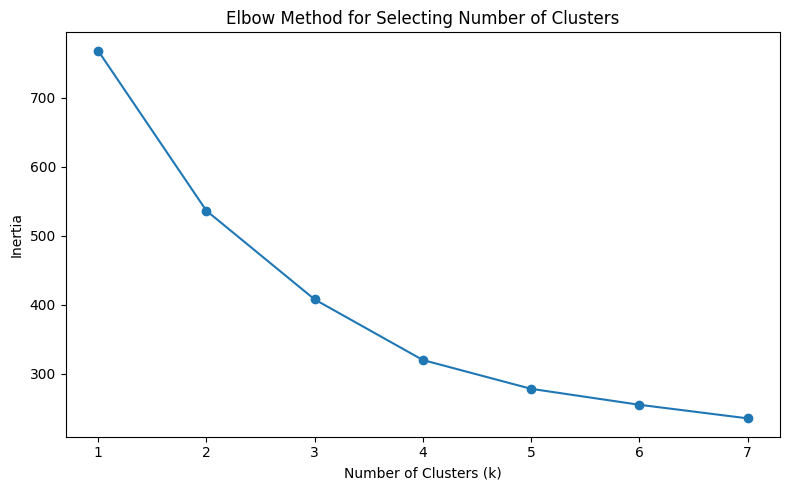

In [8]:
inertias = []

k_values = range(1, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting Number of Clusters")
plt.tight_layout()
plt.savefig("../outputs/Charts/elbow_method_clusters.png", dpi=300)
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(X_scaled)

df[
    [
        "Country Name",
        "womens_development_index",
        "education_index",
        "economic_participation_index",
        "health_index",
        "political_representation_index",
        "cluster"
    ]
].head()

,Country Name,womens_development_index,education_index,economic_participation_index,health_index,political_representation_index,cluster
0,Finland,0.829645,0.853936,0.759592,0.954033,0.751020,2
1,Iceland,0.815931,0.647533,0.883623,0.955116,0.777454,2
2,Sweden,0.815507,0.770771,0.768192,0.965213,0.757850,2
3,Norway,0.814351,0.712781,0.828024,0.963066,0.753532,2
4,Australia,0.800856,0.792299,0.827854,0.956158,0.627112,2
